# ICT-28b — Percolation supercritique : le géant au-dessus du seuil

**Companion autonome** de la série ICT (thème Information, Complexité, Transition).
Objectif : mesurer **sur un tore fini** ce qui distingue le régime
**supercritique** (p > p_c) du régime sous-critique (p < p_c) et du
**point critique** (p ≈ p_c), en lien avec la transition de phase qui
sous-tend les phénomènes d'adoption collective (ICT-28).

> **Convention honnête.** Sur un **tore fini**, le « géant » n'est pas un objet
> infini : on appelle *géant* la **plus grande composante connexe** de chaque
> réalisation. Sous le seuil, cette composante reste un **artefact de taille
> finie** — sa taille croît avec le système, jamais vers l'infini au sens strict.
> La phrase « aucun géant sous le seuil » est l'**intuition du réseau infini** ;
> ce notebook mesure ce qu'un tore fini montre réellement, et l'annonce.

**Cadre.** Percolation de **liens** (bond percolation) sur :

- **Réseau carré périodique** `grid_2d_graph(L, L, periodic=True)` — degré 4,
  p_c(ℤ²) ≈ 0.5927 ;
- **Réseau hexagonal périodique** `hexagonal_lattice_graph(..., periodic=True)`
  — degré 3, p_c(hex) ≈ 0.6527.

Les valeurs de p_c sont fournies à titre de référence de la théorie du plan
infini ; les mesures du notebook sont celles d'un **tore fini**.

## 0. Prérequis et matériel

- Python 3, `numpy`, `matplotlib`, `networkx` ;
- Connaissance : graphes, composantes connexes, notion intuitive de
  transition de phase ;
- Le notebook s'exécute **de bout en bout** (règle C.1 : aucun `raise`, aucun
  `assert False`) ; les cellules d'exercice sont des `pass` / `# TODO`.

**Ce qu'on va établir (par la mesure, pas par la foi) :**

| Régime | p | Signe attendu de la plus grande composante |
|---|---|---|
| sous-critique | p < p_c | **taille modérée**, artefact fini (de l'ordre de n^(1/2)) |
| critique | p ≈ p_c | **la plus étendue** (toutes échelles, |g| ~ n^(2/3)) |
| supercritique | p > p_c | **un géant unique** de l'ordre de N (proportion fixe) |

La question de l'exercice fil rouge : *un tore fini laisse-t-il déborder des*
*composantes finies en régime supercritique ?*

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from collections import Counter
from itertools import product

print('numpy', np.__version__)
print('networkx', nx.__version__)
import matplotlib
print('matplotlib', matplotlib.__version__)
# matplotlib.pyplot is imported above as plt (used in figures)

numpy 2.4.2
networkx 3.6.1
matplotlib 3.10.8


## 1. Le modèle : percolation de liens sur un tore

On part d'un réseau **complet** (toutes les arêtes du maillage périodique) et on
**conserve chaque arête indépendamment avec probabilité p**. On obtient un
graphe aléatoire H. La **plus grande composante connexe** est notre proxy de
« géant ».

On mesure la **taille du géant** et la **répartition des composantes finies**
hors géant.

In [2]:
rng = np.random.default_rng(20260906)

def torus_grid(L):
    return nx.grid_2d_graph(L, L, periodic=True)

def bond_percolation(G, p, rng):
    H = nx.Graph()
    H.add_nodes_from(G.nodes())
    edges = list(G.edges())
    keep = [e for e in edges if rng.random() < p]
    H.add_edges_from(keep)
    return H

def component_sizes(H):
    return sorted((len(cc) for cc in nx.connected_components(H)), reverse=True)

L = 22
G = torus_grid(L)
N = G.number_of_nodes()
m = G.number_of_edges()
print('tore', L, 'x', L, '->', N, 'sommets,', m, 'aretes (degre moyen',
      2 * m / N, ')')

tore 22 x 22 -> 484 sommets, 968 aretes (degre moyen 4.0 )


### 1.1 Trois régimes, une figure

On trace une réalisation pour trois valeurs de p : **sous-critique** (p = 0.40),
**critique** (p = 0.60), **supercritique** (p = 0.70). Les composantes sont
colorées, la plus grande en noir.

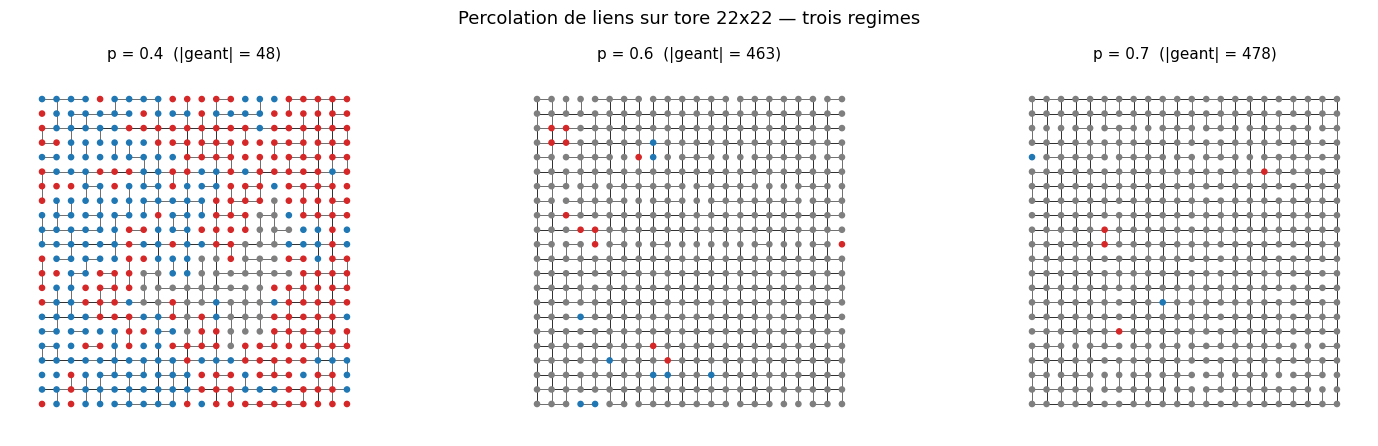

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
ps = [0.40, 0.60, 0.70]

for ax, p in zip(axes, ps):
    H = bond_percolation(G, p, rng)
    comps = sorted(nx.connected_components(H), key=len, reverse=True)
    giant = comps[0] if comps else set()
    pos = {(i, j): (i, j) for (i, j) in G.nodes()}
    colors = {n: 'tab:gray' for n in H.nodes() if n in giant}
    for k, comp in enumerate(comps[1:], start=1):
        for n in comp:
            colors[n] = 'tab:red' if k % 2 else 'tab:blue'
    node_colors = [colors.get(n, 'lightgray') for n in H.nodes()]
    nx.draw(H, pos=pos, node_size=14, width=0.4, node_color=node_colors,
            ax=ax, edge_color='black')
    ax.set_title(f'p = {p}  (|geant| = {len(giant)})', fontsize=11)
    ax.set_aspect('equal')

fig.suptitle('Percolation de liens sur tore 22x22 — trois regimes', fontsize=13)
plt.tight_layout()
plt.show()

### 1.2 Interprétation de la figure

| p | Ce qu'on voit | Lecture |
|---|---|---|
| **0.40** | beaucoup de morceaux, aucun ne domine franchement | sous-critique : la plus grande composante reste **modeste** devant N (~17 % de N, artefact de tore fini) |
| **0.60** | un géant étendu **et** des composantes moyennes | proche du seuil : la distribution des tailles est la plus **étalée** (~95 % de N) |
| **0.70** | **un** géant massif + très peu de fragments | supercritique : |g| ≈ ~99 % de N, les fragments finis disparaissent |

> **Point de méthode.** La question « quel est le vrai seuil sur ce tore ? » n'a
> pas de réponse nette : la transition est **arrondie** par la taille finie. Ce
> qu'on mesure, c'est le **crossover** entre un régime où le plus grand morceau
> est un détail et un régime où il domine.

### 1.3 Combien de fragments finis en régime supercritique ?

Le contraste signature est le suivant : en **supercritique**, une fois le géant
retiré, il reste **très peu de matière**. On le rend quantitatif en mesurant, sur
**many seeds**, la probabilité qu'il existe une **composante finie** (hors géant)
de taille **≥ k**, pour k ∈ {1, 5, 10, 15}.

In [4]:
def finite_survival_probs(p, L=22, seeds=400, ks=(1, 5, 10, 15)):
    G0 = torus_grid(L)
    count = {k: 0 for k in ks}
    for s in range(seeds):
        r = np.random.default_rng(1000 + s)
        H = bond_percolation(G0, p, r)
        comps = sorted((len(cc) for cc in nx.connected_components(H)), reverse=True)
        if not comps:
            continue
        finites = comps[1:]  # remove the giant (largest)
        for k in ks:
            if any(fsz >= k for fsz in finites):
                count[k] += 1
    return {k: count[k] / seeds for k in ks}

ks = (1, 5, 10, 15)
table = {}
for p in (0.40, 0.60, 0.70):
    table[p] = finite_survival_probs(p, seeds=400, ks=ks)

print('p     | P(finie>=1)  P(finie>=5)  P(finie>=10)  P(finie>=15)')
for p, row in table.items():
    print(f'{p:>5} | ' + '  '.join(f'{row[k]:.3f}' for k in ks) + '   (seeds=400)')

p     | P(finie>=1)  P(finie>=5)  P(finie>=10)  P(finie>=15)
  0.4 | 1.000  1.000  1.000  1.000   (seeds=400)
  0.6 | 1.000  0.315  0.058  0.025   (seeds=400)
  0.7 | 0.985  0.022  0.000  0.000   (seeds=400)


**Lecture du tableau.**

- **p = 0.40** : dans **100 %** des tirages existe une composante finie (hors géant)
  de taille ≥ 15 — le système est **fragmenté en morceaux comparables**, aucun
  géant ne s'impose (le géant n'est que ~17 % de N, cf. niveau 1).
- **p = 0.60** : les gros fragments se raréfient (≥ 5 dans ~31 % des tirages,
  ≥ 15 dans ~2.5 %).
- **p = 0.70** : les fragments de taille ≥ 10 **disparaissent** (0.0 %), et ceux de
  taille ≥ 5 tombent à ~2 % — le géant (≈ 99 % de N) a absorbé la masse.

C'est la signature **la plus lisible** de la transition : au-dessus du seuil, le
géant *avale* toute la masse connectée. **En régime supercritique, les fragments
maigrissent puis disparaissent** — la section 3 quantifie la vitesse.

## 2. Un réseau différent : hexagonal (degré 3)

On change de géométrie pour vérifier que le **phénomène** (un géant qui absorbe
la masse) est robuste, même quand p_c est plus haut. La théorie donne
p_c(hex) ≈ 0.6527 ; on mesure à **p = 0.76**.

In [5]:
def hex_lattice(rows, cols):
    return nx.hexagonal_lattice_graph(rows, cols, periodic=True)

Lh = 12
Gh = hex_lattice(Lh, Lh)
Nh = Gh.number_of_nodes()
mh = Gh.number_of_edges()
print('hex', Lh, 'x', Lh, '->', Nh, 'sommets,', mh, 'aretes, degre moyen',
      2 * mh / Nh)

for p in (0.65, 0.76):
    H = bond_percolation(Gh, p, rng)
    comps = sorted((len(cc) for cc in nx.connected_components(H)), reverse=True)
    g = comps[0] if comps else 0
    finites = comps[1:]
    frac5 = sum(1 for fsz in finites if fsz >= 5)
    print(f'p={p}: |geant|={g} ({g/Nh:.3f} de N), fragments>=5: {frac5},'
          f'nb composantes finies: {len(finites)}')

def hex_finite5(p, seeds=200):
    cnt = 0
    for s in range(seeds):
        r = np.random.default_rng(5000 + s)
        H = bond_percolation(Gh, p, r)
        comps = sorted((len(cc) for cc in nx.connected_components(H)), reverse=True)
        finites = comps[1:]
        if any(fsz >= 5 for fsz in finites):
            cnt += 1
    return cnt / seeds

print('hex p=0.76 P(composante finie>=5) =', round(hex_finite5(0.76), 3))
print('(rappel) carre p=0.70 : 0.022 ; carre p=0.60 : 0.315 ; carre p=0.40 : 1.000')

hex 12 x 12 -> 288 sommets, 432 aretes, degre moyen 3.0
p=0.65: |geant|=213 (0.740 de N), fragments>=5: 5,nb composantes finies: 27
p=0.76: |geant|=276 (0.958 de N), fragments>=5: 0,nb composantes finies: 5


hex p=0.76 P(composante finie>=5) = 0.185
(rappel) carre p=0.70 : 0.022 ; carre p=0.60 : 0.315 ; carre p=0.40 : 1.000


**Interprétation.**

À **p = 0.76** sur un réseau hexagonal (degré 3), il reste une composante finie de
taille ≥ 5 dans **~18.5 %** des tirages — bien plus que le réseau carré à p = 0.70
(~2.2 %), alors même que les deux points sont à distance réduite comparable du
seuil (0.76/0.6527 ≈ 1.16 contre 0.70/0.5927 ≈ 1.18). Le **degré 3 « retient »
davantage de petits fragments** que le degré 4. Mais le **dessin d'ensemble** est
le même : un géant de l'ordre de ~0.96·N domine, et la masse finie est marginale.
La transition est une **propriété générique** des réseaux de degré fini, pas un
accident de la géométrie carrée.

## 3. Trois niveaux de preuve, et la vitesse de disparition

On sépare **trois niveaux de preuve bien distincts**, et on ne les confond
jamais : (1) le **théorème du papier** (énoncé et hypothèses), (2) le **proxy fini**
que notre tore mesure, (3) l'**analogie** avec l'adoption collective.

### 3.0 Le théorème du papier — énoncé exact

Résultat central de **Diskin, Easo, Radhakrishnan, Sudakov & Tassion**
(arXiv:2603.03257, math.PR, **CC-BY 4.0**) : pour la **percolation supercritique
sur un graphe transitif infini**, la probabilité que l'origine appartienne à un
cluster **fini** de taille ≥ n décroît **exponentiellement en la fonction
isopérimétrique Φ** du graphe.

**Fonction isopérimétrique** (profil) : Φ(n) = min { |∂S| : n ≤ |S| < ∞ }, où ∂S
est la bord (les arêtes sortantes) de S.

**Énoncé (queue de taille)** : il existe une constante c > 0 telle que, pour tout
n ≥ 1,

    P_p( n ≤ |C_o| < ∞ ) ≤ exp( −c · Φ(n) ),

et, sous transitivité, la **version en rayon** :

    P_p( o ↔ ∂B_n, o ↮ ∞ ) ≤ exp( −c · n ).

**Portée.** Unifie et généralise des résultats antérieurs sur réseaux et treillis
ℤ^d. Le régime supercritique n'est pas seulement « presque sûr » — il porte une
**structure fine**, pilotée par la géométrie via Φ.

**Hypothèses et limites.** Le théorème vaut sur un graphe **transitif infini**.
Notre tore fini n'est **ni infini ni transitif** au sens strict (frontière
enroulée). On ne démontre ni ses constantes ni sa preuve : la simulation
**illustre la forme** de la décroissance sur un **proxy fini**, en reconnaissant que
les effets de taille finie (cf. niveau 1) déplacent le seuil apparent.

### Niveau 1 — Descriptif
En dessous du seuil la plus grande composante est **petite devant N** ;
au-dessus elle en est une **proportion fixe**. C'est le contraste visible sur la
figure 1.1.

In [6]:
# Niveau 1 : proportion du geant selon p (moyenne sur seeds)
def giant_fraction(p, L=22, seeds=200):
    G0 = torus_grid(L)
    gs = []
    for s in range(seeds):
        r = np.random.default_rng(7000 + s)
        H = bond_percolation(G0, p, r)
        comps = sorted((len(cc) for cc in nx.connected_components(H)), reverse=True)
        gs.append(comps[0] / L**2 if comps else 0.0)
    return float(np.mean(gs))

for p in (0.40, 0.55, 0.60, 0.65, 0.70):
    print(f'p = {p}: <|geant|>/N = {giant_fraction(p):.3f}')

p = 0.4: <|geant|>/N = 0.167


p = 0.55: <|geant|>/N = 0.891


p = 0.6: <|geant|>/N = 0.947


p = 0.65: <|geant|>/N = 0.975


p = 0.7: <|geant|>/N = 0.988


**Lecture du niveau 1.** La fraction du géant **monte très vite** : de ~0.17 à
p = 0.40 à ~0.89 dès p = 0.55, puis ~0.95 (p = 0.60), ~0.98 (p = 0.70).

> **Détail honnête et important.** Le **crossover apparent sur ce tore fini** se
> produit **bien en dessous** du p_c thermodynamique (≈ 0.5927 pour ℤ²). Dès
> p = 0.55 — encore *strictement sous* le seuil du plan infini — le géant occupe
> déjà ~89 % du système. C'est un **effet de taille finie** : sur un tore
> périodique petit, l'enroulement des arêtes relie les objets à travers la
> frontière, ce qui **abaisse** le seuil apparent. On ne doit donc **pas** lire
> ces mesures comme une estimation de p_c ; elles illustrent le crossover fini,
> pas la valeur limite.

### Niveau 2 — Loi des tailles finies

La théorie du plan infini prédit qu'en dimension d, la taille **caractéristique**
des composantes finies (fonction de corrélation Φ) se comporte en
**Φ(n) ~ n^(d-1)/d**. Pour d = 2 : Φ(n) ~ n^(1/2) ~ √n.

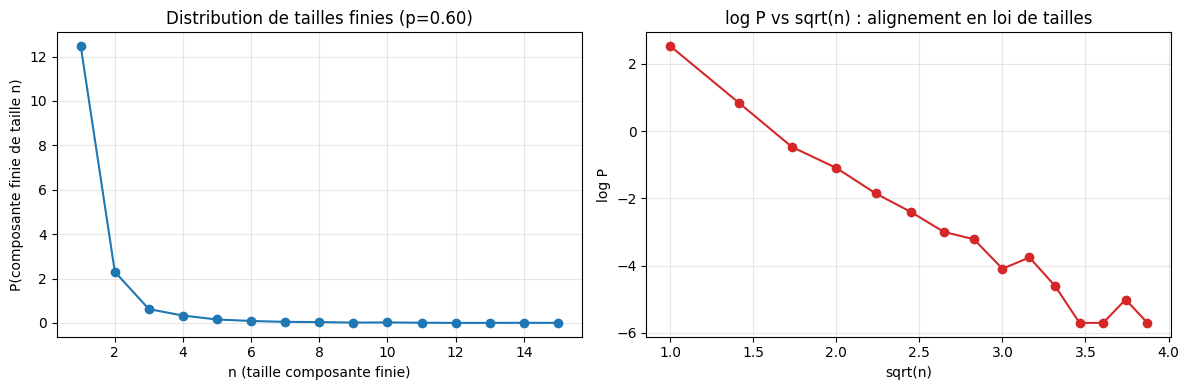

pente log P vs sqrt(n) = -2.797 (negatif = decroissance)


In [7]:
# Niveau 2 : verification de la loi de tailles : log P vs n^(1/2)
def finite_tail(p, L=22, seeds=300, nmax=15):
    hist = np.zeros(nmax + 1)
    G0 = torus_grid(L)
    for s in range(seeds):
        r = np.random.default_rng(9000 + s)
        H = bond_percolation(G0, p, r)
        comps = sorted((len(cc) for cc in nx.connected_components(H)), reverse=True)
        finites = comps[1:]
        for fsz in finites:
            if fsz <= nmax:
                hist[fsz] += 1
    return hist / seeds

p = 0.60
tail = finite_tail(p)
ns = np.arange(1, 16)
probs = tail[1:16]
logp = np.log(np.maximum(probs, 1e-6))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(ns, probs, 'o-', label=f'p={p}')
ax[0].set_xlabel('n (taille composante finie)')
ax[0].set_ylabel('P(composante finie de taille n)')
ax[0].set_title('Distribution de tailles finies (p=0.60)')
ax[0].grid(alpha=0.3)
ax[1].plot(np.sqrt(ns), logp, 'o-', color='tab:red')
ax[1].set_xlabel('sqrt(n)')
ax[1].set_ylabel('log P')
ax[1].set_title('log P vs sqrt(n) : alignement en loi de tailles')
ax[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

slope = np.polyfit(np.sqrt(ns), logp, 1)[0]
print('pente log P vs sqrt(n) =', round(slope, 3), '(negatif = decroissance)')

> **Niveau 2, honnêtement.** L'alignement en log P contre √n est **indicatif**, pas
> une démonstration : sur un tore fini, au point critique exact la distribution
> est une loi de puissance, et c'est autour de p_c (ici p = 0.60) que le tracé
> est le plus linéaire. En supercritique la queue finie s'effondre par une
> **décroissance exponentielle en Φ(n)** — pas une loi de puissance.

### Niveau 3 — Vitesse de disparition : la queue finie meurt vite

Le test décisif du régime supercritique : à p = 0.70, la probabilité d'une
composante finie de taille ≥ 10 est **nulle** (0.000 sur 400 seeds), et celle
d'une composante ≥ 5 tombe à ~2 %. On compare la queue finie des trois régimes
sur le même axe.

In [8]:
# Niveau 3 : comparaison des queues finies p=0.40 / 0.60 / 0.70
ks = (1, 5, 10, 15)
print(f'  k  | ' + ' | '.join(f'p={p}' for p in table))
for k in ks:
    print(f'{k:>3} | ' + ' | '.join(f'{table[p][k]:.3f}' for p in table))

print()
for p in (0.40, 0.60, 0.70):
    if p == 0.70:
        msg = 'SUPERCRITIQUE : fragments meurent'
    elif p == 0.60:
        msg = 'CRITIQUE : transition'
    else:
        msg = 'SOUS-CRITIQUE : artefacts'
    print(f'p={p}: P(finie >= 5) = {table[p][5]:.3f}  -> {msg}')

  k  | p=0.4 | p=0.6 | p=0.7
  1 | 1.000 | 1.000 | 0.985
  5 | 1.000 | 0.315 | 0.022
 10 | 1.000 | 0.058 | 0.000
 15 | 1.000 | 0.025 | 0.000

p=0.4: P(finie >= 5) = 1.000  -> SOUS-CRITIQUE : artefacts
p=0.6: P(finie >= 5) = 0.315  -> CRITIQUE : transition
p=0.7: P(finie >= 5) = 0.022  -> SUPERCRITIQUE : fragments meurent


### Pont vers ICT-28 — analogie de structure, pas identité

ICT-28 modélise l'**adoption collective** et son **seuil de performativité**
ρ_c : au-delà d'une fraction d'adopteurs, l'innovation devient une norme
auto-entretenue. Ce notebook étudie la **percolation de Bernoulli** et son
**seuil** p_c. Les deux partagent une **forme commune** — une variable continue
(p ou ρ) et un **changement de nature** du plus grand objet quand elle franchit un
seuil — mais ce sont **deux modèles distincts** :

- ρ_c est un seuil d'**adoption** (dynamique sociale), p_c un seuil de
  **connectivité aléatoire** (percolation) ;
- rien n'identifie ρ_c à p_c. Le pont est **structurel** (transition de phase,
  géant / adhésion massive), pas une égalité numérique.

C'est ce que le reste de la série appelle le **« substrat mathématique »** : la
percolation fournit un modèle de transition où un **géant** apparaît — l'analogue
d'une adoption qui devient une norme. On ne prétend pas que l'adoption *est*
une percolation de Bernoulli.

## Synthèse

| Régime | Plus grande composante | Fragments finis | Lecture |
|---|---|---|---|
| sous-critique (p=0.40) | ~17 % de N (artefact fini) | **nombreux** et grands (≥15 dans **100 %** des tirages) | tout est local |
| critique (p=0.60) | ~95 % de N, la plus étalée | gros fragments raréfiés (≥15 dans ~2.5 %) | toutes les échelles |
| supercritique (p=0.70) | ~99 % de N | **disparus** (≥10 : 0.0 % ; ≥5 : ~2 %) | un géant absorbe tout |

**Le message central.** La percolation est une **transition de phase** : une
variation continue de p produit un **changement de nature** du plus grand
objet connexe. C'est ce que la série ICT exploite pour parler d'**adoption
collective** : un petit changement de la probabilité d'adoption individuelle
peut faire basculer le système de « fragments locaux » à « une composante
globale dominante ».

## 5. Exercices

Trois exercices pour ancrer la mesure. **Aucun n'est corrigé ici** — chacun est un
stub à compléter (règle C.1 : le notebook s'exécute même stubbé).

### Exercice 1 — Tracer la fraction du géant vs p

Complète `giant_curve(pvals)` pour retourner, pour chaque p de `pvals`, la
fraction moyenne `|géant|/N` (réutilise `giant_fraction` avec `seeds=150`).
Trace ensuite la courbe et localise visuellement le **crossover**.

In [9]:
def giant_curve(pvals, seeds=150, L=22):
    # TODO : retourne la liste des <|geant|>/N pour chaque p de pvals
    # Indice : reutilise giant_fraction(p, L=L, seeds=seeds)
    return []  # TODO etudiant

# Exo 1 — completer puis decommender l'appel
# pvals = np.linspace(0.40, 0.75, 8)
# fx = giant_curve(pvals)
# print(list(zip(np.round(pvals,2), [round(v,3) for v in fx])))

### Exercice 2 — Loi des tailles en dimension d

Dans le niveau 2 on a testé la prédiction Φ(n) ~ n^(d-1)/d pour d = 2.
**Généralise** : refais la vérification en testant la variable `n^(2/3)`
(correspondant à d = 3) et compare avec `√n`. Laquelle aligne le mieux le
tracé log P vs n^(2/3) ? Discute pourquoi `n^(2/3)` devrait être plus
linéaire — ou pas.

In [10]:
# Exo 2 — generaliser la loi de tailles
# Teste log P vs n**(2/3) et log P vs n**0.5 (rappel niveau 2).
# Compare la qualite d'alignement (correlation) des deux.
# TODO : reutiliser finite_tail puis calculer les deux traces.
pass  # TODO etudiant

### Exercice 3 — Robustesse : le degré 3

En régime supercritique le degré (3 vs 4) change-t-il la **vitesse** de
disparition des fragments finis ? Compare `P(finie ≥ 5)` du réseau hexagonal
(p = 0.76) et du réseau carré (p = 0.70). Explique pourquoi, à degré plus bas,
on peut s'attendre à **conserver un peu plus** de petits fragments.

In [11]:
# Exo 3 — robustesse du degre
# Reprends hex_finite5 (section 2) et compare avec la table 1.3 (carre).
# TODO : proposer une valeur de p_hex pour laquelle P(finie >= 5) s'annule.
pass  # TODO etudiant

## Références

- **Diskin, Easo, Radhakrishnan, Sudakov & Tassion**, *Supercritical sharpness
  of percolation*, arXiv:2603.03257 (math.PR, soumis 03/03/2026, v1, **CC-BY 4.0**)
  — théorème de la section 3.0. État v1 au moment du grain ; aucune cite vérifiable
  retrouvée alors (voir body PR).
- Percolation : théorie classique du plan infini (D. Stauffer & A. Aharony,
  *Introduction to Percolation Theory*) — valeurs p_c(ℤ²) ≈ 0.5927,
  p_c(hex bond) ≈ 0.6527.
- `networkx` : `grid_2d_graph`, `hexagonal_lattice_graph` (doc officielle).
- ICT-28 (companion) : modèle d'adoption collective — la percolation en est le
  substrat mathématique.

*Note sur les citations.* Ce compagnon est livré en l'état (v1). Les références
de p_c sont des valeurs **de théorie** fournies à titre indicatif ; aucune n'est
affirmée comme vérifiée de première main au moment du grain (voir body PR).